In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stat

cancers = ['ccRCC', 'Melanoma', 'NSCLC']

name_dictionary = {
    'Avatars K5': 'avatarsk5',
    'Avatars K10': 'avatarsk10',
    'CTGAN': 'ctgan',
    'Gaussian Copula': 'gaussiancopula',
    'Synthpop': 'synthpop',
    'TVAE': 'tvae'
}

seeds = [0,1,2,3,42]
# datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
MetaScore = {}

n_sample = 1

## **1.Univariate Similarity**

In [8]:
rows_90_samples = []

for cancer in cancers:
    for name, pathname in name_dictionary.items():
        for seed in seeds:
            try:
                # Đọc Clinical Score
                uni_clinical_path = f'../{cancer}/BroadUtility/UniClinicalSimi/UniClinicalSimi_{seed}/Detail_score_{pathname}_{seed}.csv'
                uni_clinical_df = pd.read_csv(uni_clinical_path)
                score_clinical = uni_clinical_df["Score"].fillna(0).mean()

                # Đọc Omic Score
                uni_omic_path = f'../{cancer}/BroadUtility/UniTranscriptomicsSimi/UniTranscriptomicsSimi_{seed}/Detail_score_{pathname}_{seed}.csv'
                uni_omic_df = pd.read_csv(uni_omic_path)
                score_omic = uni_omic_df["Score"].fillna(0).mean()

                # Tính Overall Score cho 1 replicate cụ thể
                overall_score = 0.5 * (score_clinical + score_omic)
                
                rows_90_samples.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': overall_score,
                    'Identifier': f"{cancer}_{name}_{seed}"
                })
            except Exception as e:
                print(f"Bỏ lỡ dữ liệu tại {cancer}-{name}-Seed{seed}: {e}")

In [9]:
df_uni_90 = pd.DataFrame(rows_90_samples)


df_uni_90['Overall_Rank'] = df_uni_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

uni_rank_derived_score = {}
for model_name in name_dictionary.keys():
    # Lấy trung bình hạng của model này (trung bình của 15 giá trị hạng)
    avg_rank = df_uni_90[df_uni_90['Model'] == model_name]['Overall_Rank'].mean()
    uni_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['UnivariateScore'] = uni_rank_derived_score

## **Bivariate Similarity**

In [10]:
rows_bi_90 = []

for cancer in cancers:
    for name, pathname in name_dictionary.items():
        for seed in seeds:
            try:
                # Load Bivariate Clinical (.npy)
                bi_clinical_path = f'../{cancer}/BroadUtility/PairwiseClinical/PairwiseClinical_{seed}/bivariate_{pathname}_{seed}_all.npy'
                bi_clinical_data = np.load(bi_clinical_path)
                score_clinical = np.mean(bi_clinical_data)

                # Load Bivariate Omic (.npy)
                bi_omic_path = f'../{cancer}/BroadUtility/PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/{pathname}_{seed}_all.npy'
                bi_omic_data = np.load(bi_omic_path)
                score_omic = np.mean(bi_omic_data)

                cross_path = f'../{cancer}/BroadUtility/PairwiseCrossGroup/CrossGroup_{seed}/{pathname}_{seed}_cross_group_full.csv'
                score_cross = np.mean(pd.read_csv(cross_path)['Score'].values)

                # Tính Overall Bivariate Score cho replicate này
                overall_score = (1/3) * (score_clinical + score_omic+score_cross)
                
                rows_bi_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': overall_score,
                    'Identifier': f"{cancer}_{name}_{seed}"
                })
            except Exception as e:
                print(f"Loading Err {cancer}-{name}-Seed{seed}: {e}")

In [11]:
df_bi_90 = pd.DataFrame(rows_bi_90)

df_bi_90['Overall_Rank'] = df_bi_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

bi_rank_derived_score = {}
for model_name in name_dictionary.keys():
  
    avg_rank = df_bi_90[df_bi_90['Model'] == model_name]['Overall_Rank'].mean()
    bi_rank_derived_score[model_name] = avg_rank


MetaScore['BivariateScore'] = bi_rank_derived_score

## **GCS - Differential Gene Expression**

In [12]:
# 1. Thu thập dữ liệu từ tất cả các file pcs_score.csv của 3 loại ung thư
rows_gcs_90 = []
all_tools = name_dictionary.keys()

for cancer in cancers:
    try:
        # Đọc file điểm GCS (thường index là danh sách Gene hoặc Pathway, cột là Tool_Seed)
        gcs_df = pd.read_csv(f"../{cancer}/NarrowUtility/DGE/PCS/pcs_score.csv", index_col=0)
        
        for name, pathname in name_dictionary.items():
            for seed in seeds:
                # Xác định tên cột cho cặp Tool + Seed cụ thể (Ví dụ: CTGAN_0)
                col_name = f"{name}_{seed}"
                
                if col_name in gcs_df.columns:
                    # Lấy trung bình điểm của toàn bộ các hàng trong cột đó cho seed này
                    score_value = gcs_df[col_name].mean()
                elif name in gcs_df.columns:
                    # Nếu file không chia seed mà chỉ có cột tên Model chung
                    score_value = gcs_df[name].mean()
                else:
                    # Nếu không tìm thấy dữ liệu, gán 0.0 (tệ nhất)
                    score_value = 0.0
                
                rows_gcs_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': score_value,
                    'Identifier': f"{cancer}_{name}_{seed}"
                })
                
    except FileNotFoundError:
        print(f"Warning: File not found for {cancer}. Filling with 0.0")
        for name in all_tools:
            for seed in seeds:
                rows_gcs_90.append({
                    'Cancer': cancer, 'Model': name, 'Seed': seed, 
                    'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
                })

In [13]:
# 2. Tạo DataFrame chứa 90 quan sát
df_gcs_90 = pd.DataFrame(rows_gcs_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# Điểm GCS càng cao (gần 1) càng tốt -> ascending=False
df_gcs_90['Overall_Rank'] = df_gcs_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
# Tính trung bình thứ hạng của từng Tool dựa trên 15 kết quả (3 cancers * 5 seeds)
gcs_rank_derived_score = {}
for model_name in all_tools:
    avg_rank = df_gcs_90[df_gcs_90['Model'] == model_name]['Overall_Rank'].mean()
    gcs_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['DGE'] = gcs_rank_derived_score

## **PCS - GSEA**

In [14]:
rows_pcs_90 = []
all_tools = name_dictionary.keys()

for cancer in cancers:
    try:
        # Đọc file PCS score của GSEA
        pcs_df = pd.read_csv(f"../{cancer}/NarrowUtility/GSEA/PCS_Jiter/pcs_score.csv", index_col=0)
        
        for name in all_tools:
            for seed in seeds:
                # Định danh cột cho từng seed (ví dụ: CTGAN_0)
                col_name = f"{name}_{seed}"
                
                if col_name in pcs_df.columns:
                    # Tính trung bình điểm PCS của các Pathway trong seed này
                    score_value = pcs_df[col_name].mean()
                elif name in pcs_df.columns:
                    # Backup nếu file chỉ có cột tên Model chung (đã trung bình sẵn)
                    score_value = pcs_df[name].mean()
                else:
                    # Gán 0.0 nếu không tìm thấy dữ liệu cho seed này
                    score_value = 0.0
                
                rows_pcs_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': score_value,
                    'Identifier': f"{cancer}_{name}_{seed}"
                })
                
    except FileNotFoundError:
        print(f"Warning: GSEA file not found for {cancer}. Filling with 0.0")
        for name in all_tools:
            for seed in seeds:
                rows_pcs_90.append({
                    'Cancer': cancer, 'Model': name, 'Seed': seed, 
                    'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
                })



In [15]:

df_pcs_90 = pd.DataFrame(rows_pcs_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# PCS càng cao (độ tương đồng Pathway) càng tốt -> ascending=False
df_pcs_90['Overall_Rank'] = df_pcs_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
pcs_rank_derived_score = {}
for model_name in all_tools:
    # Lấy trung bình hạng của model này từ 15 lần quan sát (3 cancers * 5 seeds)
    avg_rank = df_pcs_90[df_pcs_90['Model'] == model_name]['Overall_Rank'].mean()
    pcs_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore cho mục GSEA
MetaScore['GSEA'] = pcs_rank_derived_score


## **KSComplement - ssGSEA**

In [16]:
# 1. Thu thập dữ liệu ssGSEA từ toàn bộ 90 trường hợp (3 cancers * 6 tools * 5 seeds)
rows_ssgsea_90 = []
all_tools = name_dictionary.keys()

for cancer in cancers:
    for name, pathname in name_dictionary.items():
        for seed in seeds:
            try:
                # Đường dẫn file ssGSEA cụ thể cho từng cancer và seed
                file_path = f'../{cancer}/NarrowUtility/ssGSEA/KSStatistic/Seed_{seed}/Detail_score_{pathname}_{seed}.csv'
                
                # Đọc dữ liệu và tính trung bình score (thường là KS Statistic Similarity)
                df = pd.read_csv(file_path)
                score_val = df["Score"].fillna(0).mean()
                
                rows_ssgsea_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': score_val,
                    'Identifier': f"{cancer}_{name}_{seed}"
                })
            except FileNotFoundError:
                print(f"Warning: Missing ssGSEA file for {cancer}-{name}-Seed{seed}")
                rows_ssgsea_90.append({
                    'Cancer': cancer, 'Model': name, 'Seed': seed, 
                    'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
                })
            except Exception as e:
                print(f"Error at {cancer}-{name}-Seed{seed}: {e}")
                rows_ssgsea_90.append({'Cancer': cancer, 'Model': name, 'Seed': seed, 'Value': 0.0})


In [17]:
df_ssgsea_90 = pd.DataFrame(rows_ssgsea_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# ssGSEA similarity càng cao càng tốt -> ascending=False
df_ssgsea_90['Overall_Rank'] = df_ssgsea_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
# Trung bình hạng dựa trên 15 lần quan sát của mỗi Model trên toàn bộ dataset
ssGSEA_rank_derived_score = {}
for model_name in all_tools:
    avg_rank = df_ssgsea_90[df_ssgsea_90['Model'] == model_name]['Overall_Rank'].mean()
    ssGSEA_rank_derived_score[model_name] = avg_rank

# Lưu vào MetaScore
MetaScore['ssGSEA'] = ssGSEA_rank_derived_score

## **Aitchinson Distance - Cell Deconvolution**

In [90]:

# 1. Thu thập dữ liệu Aitchison Distance từ toàn bộ 90 trường hợp
rows_cell_90 = []
all_tools = name_dictionary.keys()

for cancer in cancers:
    # try:
        # Xử lý đường dẫn file linh hoạt theo từng cancer
        if cancer == 'NSCLC':
            path = f"../NSCLC/NarrowUtility/CellDeco/AitchisonDistance/Score.csv"
        elif cancer == 'Melanoma':
            path = f"../{cancer}/NarrowUtility/CellDecovo/AitchisonDistance/Score.csv"
        elif cancer == 'ccRCC':
            path = f'../{cancer}/NarrowUtility/CellDecovo/AitchisonDistance/Score.csv'
        
        # Đọc file Score (thường có các cột/hàng là Model_Seed)
        score_df = pd.read_csv(path, index_col=0)
        
        for name in all_tools:
            for seed in seeds:
                
                if name in score_df.index:
                    val = score_df.loc[name, str(seed)]
                else:
                    # Nếu không tìm thấy, gán một khoảng cách rất lớn (Penalty)
                    val = 0.0 
                identifier = f"{name}_{seed}"
                rows_cell_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': val,
                    'Identifier': f"{cancer}_{identifier}"
                })
                
    # except FileNotFoundError:
    #     print(f"Warning: Cell Decovo file not found for {cancer}. Filling with 999.0")
    #     for name in all_tools:
    #         for seed in seeds:
    #             rows_cell_90.append({
    #                 'Cancer': cancer, 'Model': name, 'Seed': seed, 
    #                 'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
    #             })


In [92]:

# 2. Tạo DataFrame chứa 90 dòng
df_cell_90 = pd.DataFrame(rows_cell_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# QUAN TRỌNG: Aitchison Distance càng NHỎ càng tốt -> ascending=True
df_cell_90['Overall_Rank'] = df_cell_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
aitchinson_rank_derived_score = {}
for model_name in all_tools:
    # Trung bình thứ hạng của mỗi model trên 15 lần thử nghiệm (3 cancers * 5 seeds)
    avg_rank = df_cell_90[df_cell_90['Model'] == model_name]['Overall_Rank'].mean()
    aitchinson_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['Cell Deconvolution'] = aitchinson_rank_derived_score

## **C-index - Survival Analysis**

In [20]:
# 1. Thu thập dữ liệu Survival từ toàn bộ 90 trường hợp (3 cancers * 6 tools * 5 seeds)
rows_sa_90 = []
algo = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']

for cancer in cancers:
    for seed in seeds:
        try:
            # Xác định đường dẫn file dựa trên loại ung thư
            if cancer == 'ccRCC':
                base_path = f"../ccRCC/NarrowUtility/SA/SA_Nivo_Benefit/Seed_{seed}"
            elif cancer == 'Melanoma':
                base_path = f"../Melanoma/NarrowUtility/SA/CRPR_PD/Seed_{seed}"
            else: # NSCLC
                base_path = f"../NSCLC/NarrowUtility/SA/CRPR_PD/Seed_{seed}"

            # Đọc điểm OS và PFS
            df_os = pd.read_csv(f"{base_path}/Scores.csv").iloc[1:,:]
            df_pfs = pd.read_csv(f"{base_path}/Scores_PFS.csv").iloc[1:,:]
            
            # Chuyển đổi sang numeric và fillna(0) để xử lý các model bị lỗi/không hội tụ
            scores_os = pd.to_numeric(df_os['C-index_score']).fillna(0).values
            scores_pfs = pd.to_numeric(df_pfs['C-index_score']).fillna(0).values
            
            # Tính trung bình OS và PFS cho 6 model trong seed này
            combined_scores = (scores_os + scores_pfs) / 2

            for i, name in enumerate(algo):
                rows_sa_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': combined_scores[i],
                    'Identifier': f"{cancer}_{name}_{seed}"
                })

        except Exception as e:
            print(f"Error at {cancer} seed {seed}: {e}")
            # Nếu thiếu file, gán điểm 0 cho toàn bộ 6 model của seed đó
            for name in algo:
                rows_sa_90.append({
                    'Cancer': cancer, 'Model': name, 'Seed': seed, 
                    'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
                })

In [21]:
# 2. Tạo DataFrame chứa 90 quan sát
df_sa_90 = pd.DataFrame(rows_sa_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# C-index càng cao càng tốt -> ascending=False
df_sa_90['Overall_Rank'] = df_sa_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
cindex_rank_derived_score = {}
for model_name in name_dictionary.keys():
    # Lấy trung bình hạng của mỗi model dựa trên 15 lần quan sát (3 cancers * 5 seeds)
    avg_rank = df_sa_90[df_sa_90['Model'] == model_name]['Overall_Rank'].mean()
    cindex_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore
MetaScore['Survival Analysis'] = cindex_rank_derived_score

## **Privacy Score**

In [22]:
# 1. Thu thập dữ liệu Privacy từ 90 quan sát (3 cancers * 6 tools * 5 seeds)
rows_privacy_90 = []
all_tools = name_dictionary.keys()

for cancer in cancers:
    try:
        # Đọc file điểm Privacy tổng thể cho loại ung thư mục tiêu
        # Giả định file có index là Tool_Seed (ví dụ: 'CTGAN_0')
        privacy_path = f'../FigurePrivacy/overal_privacy_score_{cancer}.csv'
        privacy_df = pd.read_csv(privacy_path, index_col=0)
        
        # Đồng bộ cấu trúc: Đảm bảo Tool_Seed nằm ở Index
        if any("_" in str(col) for col in privacy_df.columns):
            privacy_df = privacy_df.T

        for name in all_tools:
            for seed in seeds:
                # Định danh Tool_Seed cụ thể
                identifier = f"{name}_{seed}"
                
                if identifier in privacy_df.index:
                    score_value = privacy_df.loc[identifier].mean()
                elif name in privacy_df.index:
                    # Backup nếu file chỉ lưu tên Model chung
                    score_value = privacy_df.loc[name].mean()
                else:
                    # Nếu thiếu dữ liệu, gán điểm 0.0 (nguy cơ rò rỉ cao nhất/không an toàn)
                    score_value = 0.0
                
                rows_privacy_90.append({
                    'Cancer': cancer,
                    'Model': name,
                    'Seed': seed,
                    'Value': score_value,
                    'Identifier': f"{cancer}_{identifier}"
                })

    except FileNotFoundError:
        print(f"Warning: Privacy file not found for {cancer}.")
        for name in all_tools:
            for seed in seeds:
                rows_privacy_90.append({
                    'Cancer': cancer, 'Model': name, 'Seed': seed, 
                    'Value': 0.0, 'Identifier': f"{cancer}_{name}_{seed}"
                })

In [23]:
# 2. Tạo DataFrame chứa 90 quan sát
df_privacy_90 = pd.DataFrame(rows_privacy_90)

# 3. THỰC HIỆN RANKING TỔNG THỂ TRÊN 90 MẪU
# Privacy càng cao càng an toàn -> ascending=False
df_privacy_90['Overall_Rank'] = df_privacy_90['Value'].rank(ascending=False, method='min').astype(int)/n_sample

# 4. TÍNH DERIVED SCORE (AVERAGE RANK) CHO METASCORE
privacy_rank_derived_score = {}
for model_name in all_tools:
    # Tính trung bình thứ hạng của mỗi model trên 15 lần thử nghiệm (3 cancers * 5 seeds)
    avg_rank = df_privacy_90[df_privacy_90['Model'] == model_name]['Overall_Rank'].mean()
    privacy_rank_derived_score[model_name] = avg_rank

# Cập nhật vào MetaScore cuối cùng
MetaScore['Privacy'] = privacy_rank_derived_score

## **Meta-Score**

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DATASET_COLORS = {
    "Origin": "#4d4d4d",
    "Avatars K5": "#66c2a5",
    "Avatars K10": "#fc8d62",
    "CTGAN": "#8da0cb",
    "Gaussian Copula": "#e78ac3",
    "Synthpop": "#a6d854",
    "TVAE": "#ffd92f",
}

COMPONENT_COLORS = {
    'Broad Utility': '#3498db',
    'Narrow Utility': '#9b59b6',
    'Privacy': '#e74c3c'
}


def plot_weighted_composite_scores(
    MetaScore: dict,
    broad_weight: float = 0.3,
    narrow_weight: float = 0.5,
    privacy_weight: float = 0.2,
    figsize: tuple = (10, 7),
    save_path: str = None,
    orientation: str = 'horizontal',
):
    """
    Plot weighted composite scores as stacked bars.
    Assumes MetaScore values are already normalized (0-1 range).
    """
    try:
        plt.style.use(["science", "nature", "notebook"])
    except Exception:
        pass
    
    plt.rcParams.update({
        'text.usetex': False,
        'axes.edgecolor': '#333333',
        'xtick.minor.visible': False,
        'ytick.minor.visible': False,
        'xtick.top': False,
        'ytick.right': False,
    })
    
    df = pd.DataFrame(MetaScore)
    df_final = pd.DataFrame()
    
    # Broad Utility: average of Univariate and Bivariate, weighted
    df_final['Broad Utility'] = (
        (df['UnivariateScore'] + df['BivariateScore']) / 2
    ) * broad_weight
    
    # Narrow Utility: average of 5 narrow metrics, weighted
    narrow_metrics = ['DGE', 'GSEA', 'ssGSEA', 'Cell Deconvolution', 'Survival Analysis']
    df_final['Narrow Utility'] = df[narrow_metrics].mean(axis=1) * narrow_weight
    
    # Privacy: direct weighted score
    df_final['Privacy'] = df['Privacy'] * privacy_weight
    
    # Sort
    df_final['Total'] = df_final.sum(axis=1)
    df_final = df_final.sort_values('Total', ascending=(orientation == 'vertical')).drop(columns='Total')
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    datasets = df_final.index.tolist()
    n_datasets = len(datasets)
    
    if orientation == 'horizontal':
        y = np.arange(n_datasets)
        height = 0.6
        left = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.barh(y, values, height, left=left, label=component,
                          color=color, edgecolor='white', linewidth=1.5, alpha=0.9)
            
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.02:  # Show label if segment wide enough
                    ax.text(left[i] + val / 2, bar.get_y() + bar.get_height() / 2,
                           f'{val:.2f}', ha='center', va='center',
                           color='white', fontsize=9, fontweight='bold')
            
            left += values
        
        # Total labels
        for i, total in enumerate(left):
            ax.text(total + 0.02, i, f'{total:.2f}',
                   ha='left', va='center', color='black', fontsize=10, fontweight='bold')
        
        ax.set_xlabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_ylabel('SDG Methods', fontsize=12, fontweight='bold')
        ax.set_yticks(y)
        ax.set_yticklabels([f"$\\mathbf{{{ds}}}$" for ds in datasets], fontsize=11)
        
        for tick_label, dataset in zip(ax.get_yticklabels(), datasets):
            tick_label.set_color(DATASET_COLORS.get(dataset, '#333333'))
        
        ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_xlim(0, left.max() * 1.15)
        legend_loc = 'upper right'
        
    else:  # vertical
        x = np.arange(n_datasets)
        width = 0.6
        bottom = np.zeros(n_datasets)
        
        for component in ['Broad Utility', 'Narrow Utility', 'Privacy']:
            values = df_final[component].values
            color = COMPONENT_COLORS[component]
            
            bars = ax.bar(x, values, width, bottom=bottom, label=component,
                         color=color, edgecolor='white', linewidth=1.5, alpha=0.9)
            
            for i, (bar, val) in enumerate(zip(bars, values)):
                if val > 0.02:
                    ax.text(bar.get_x() + bar.get_width() / 2, bottom[i] + val / 2,
                           f'{val:.2f}', ha='center', va='center',
                           color='white', fontsize=9, fontweight='bold')
            
            bottom += values
        
        # Total labels
        for i, total in enumerate(bottom):
            ax.text(i, total + 0.02, f'{total:.2f}',
                   ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')
        
        ax.set_ylabel('Rank-derived score', fontsize=12, fontweight='bold')
        ax.set_xlabel('SDG methods', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f"$\\mathbf{{{ds}}}$" for ds in datasets],
                          rotation=45, ha='right', fontsize=11)
        
        for tick_label, dataset in zip(ax.get_xticklabels(), datasets):
            tick_label.set_color(DATASET_COLORS.get(dataset, '#333333'))
        
        ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.5)
        ax.set_ylim(0, bottom.max() * 1.1)
        legend_loc = 'upper left'
    
    # ax.set_title('Weighted Composite Score: Broad vs Narrow vs Privacy',
    #             fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc=legend_loc, frameon=True, fontsize=10, fancybox=True, shadow=True)
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    
    df_final['Total'] = df_final.sum(axis=1)
    return fig, df_final.sort_values('Total', ascending=True)  # ascending=True vì lower is better

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-s

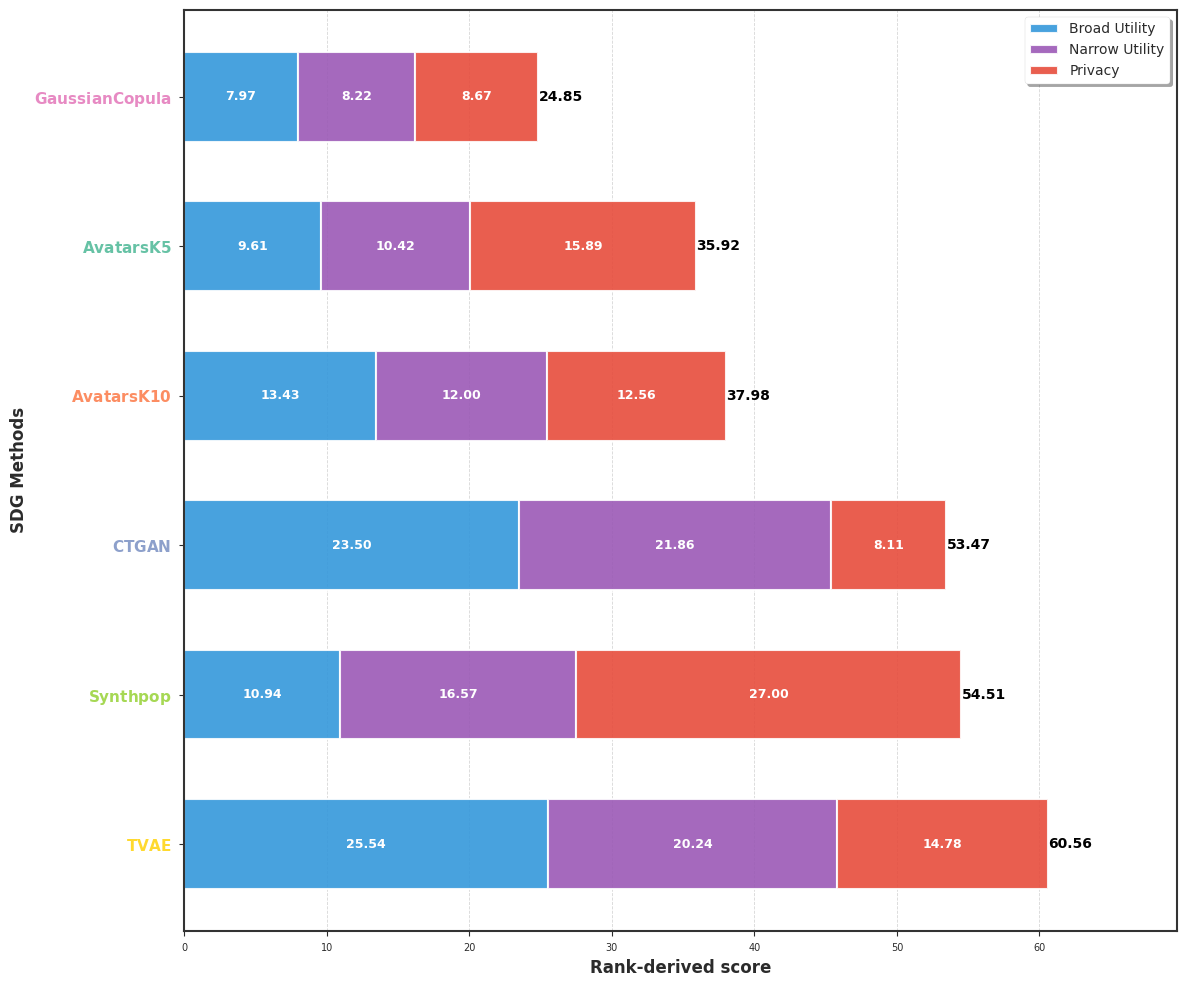

                 Broad Utility  Narrow Utility    Privacy      Total
Gaussian Copula       7.966667        8.217778   8.666667  24.851111
Avatars K5            9.611111       10.422222  15.888889  35.922222
Avatars K10          13.433333       11.995556  12.555556  37.984444
CTGAN                23.500000       21.857778   8.111111  53.468889
Synthpop             10.944444       16.568889  27.000000  54.513333
TVAE                 25.544444       20.240000  14.777778  60.562222


In [100]:
# Plot and get results
fig, results_df = plot_weighted_composite_scores(
    MetaScore=MetaScore,
    broad_weight=1/3,
    narrow_weight=1/3,
    privacy_weight=1/3,
    figsize=(12, 10),
     orientation='horizontal',
    save_path = 'MetaScore_all.pdf'
)

results_df.to_csv('MetaScore_all.csv', index = True)
print(results_df.to_string())

In [96]:
import json

# Tên file muốn lưu
file_path = "MetaScore_all.json"

# Lưu dictionary
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(MetaScore, f, indent=4, ensure_ascii=False)

In [97]:
# Danh sách các df và tên metric tương ứng
dfs = [df_uni_90, df_bi_90, df_gcs_90, df_pcs_90, 
       df_ssgsea_90, df_cell_90, df_sa_90, df_privacy_90] # Liệt kê đủ 8 df
metric_names = ['Univariate', 'Bivariate', 'DGE', 'GSEA', 
                'ssGSEA','Cell deconvolution','Survival analysis','Privacy']     # Tên gợi nhớ cho 8 metric

# 1. Hợp nhất các DF lại thành một bảng lớn
combined_df = None

for df, name in zip(dfs, metric_names):
    # Chỉ lấy các cột định danh và cột giá trị, đổi tên Value thành tên Metric
    temp_df = df[['Cancer', 'Model', 'Seed', 'Value']].rename(columns={'Value': name})
    
    if combined_df is None:
        combined_df = temp_df
    else:
        # Merge dựa trên các cột định danh để đảm bảo so sánh đúng hàng đúng lớp
        combined_df = pd.merge(combined_df, temp_df, on=['Cancer', 'Model', 'Seed'])

# Bây giờ combined_df sẽ có dạng: Cancer, Model, Seed, Uni, Bi, Privacy...

In [98]:
corr_matrix = combined_df[metric_names].corr(method = 'spearman')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-s

<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica Neue, Arial
findfont: Generic family 'sans-s

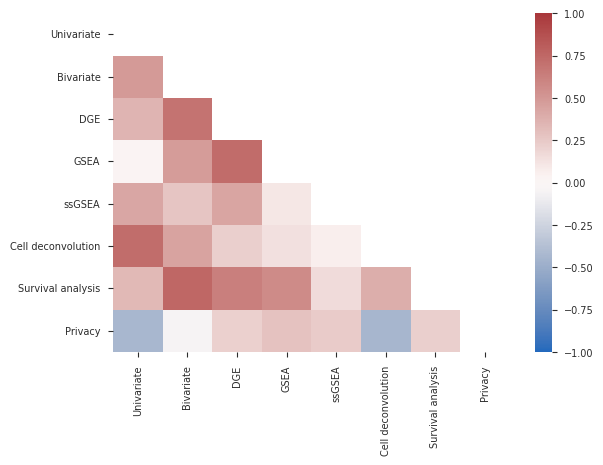

In [99]:
mask = np.triu(corr_matrix)
sns.heatmap(corr_matrix,mask=mask,cmap="vlag",vmin=-1, vmax=1)